Classificação

Dengue Detection Dataset

📌 Overview
This dataset contains clinical blood parameters used for the detection of dengue disease. It includes key hematological features commonly analyzed in medical diagnostics and can be used for building machine learning models for disease prediction.

📊 Dataset Description
The dataset consists of patient-level clinical data, including blood test results such as hemoglobin levels, white blood cell count, platelet count, and other related parameters. These features are critical indicators in identifying dengue infection.

In [18]:
import pandas as pd

In [19]:
dados = pd.read_csv('Dengue_diseases.csv')

In [ ]:
dados.head(3)

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1


In [ ]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          989 non-null    int64  
 1   gender                       989 non-null    str    
 2   hemoglobin_g_dl              989 non-null    float64
 3   wbc_count                    965 non-null    float64
 4   differential_count           989 non-null    int64  
 5   rbc_count                    989 non-null    int64  
 6   platelet_count               973 non-null    float64
 7   platelet_distribution_width  970 non-null    float64
 8   dengue_label                 989 non-null    int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 69.7 KB


In [7]:
dados.isnull().sum()

age                            0
gender                         0
hemoglobin_g_dl                0
wbc_count                      0
differential_count             0
rbc_count                      0
platelet_count                 0
platelet_distribution_width    0
dengue_label                   0
dtype: int64

In [20]:
dados.fillna(dados.mean(numeric_only=True), inplace=True)

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1
...,...,...,...,...,...,...,...,...,...
984,27,Female,11.6,9400.0,1,1,400000.0,39.9,0
985,19,Female,15.8,7400.0,1,1,320560.0,56.0,0
986,54,Female,11.9,7500.0,1,1,345000.0,44.4,0
987,34,Male,14.6,9500.0,1,1,326000.0,41.9,0


In [21]:
dados = pd.get_dummies(dados)

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = dados.drop('dengue_label', axis=1).values
y = dados['dengue_label'].values

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state=7)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


classificacao = {
    'Regressão Logística': {
        'modelo': LogisticRegression(max_iter=1000),
        'params': {'modelo__C': [0.1, 1.0, 10.0]}
    },
    'KNN': {
        'modelo': KNeighborsClassifier(),
        'params': {'modelo__n_neighbors': [3, 5, 7, 9]}
    },
    'Árvore de Decisão': {
        'modelo': DecisionTreeClassifier(random_state=42),
        'params': {'modelo__max_depth': [None, 5, 10], 'modelo__min_samples_split': [2, 5]}
    },
    'SVM': {
        'modelo': SVC(),
        'params': {'modelo__C': [0.1, 1.0, 10.0], 'modelo__kernel': ['linear', 'rbf']}
    },
    'MLP (Rede Neural)': {
        'modelo': MLPClassifier(max_iter=3000, random_state=42),
        'params': {
            'modelo__hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'modelo__activation': ['relu', 'tanh'],
            'modelo__solver': ['adam', 'sgd']
        }
    }
}



Regressão Logística
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        87
           1       0.94      0.94      0.94       161

    accuracy                           0.93       248
   macro avg       0.92      0.92      0.92       248
weighted avg       0.93      0.93      0.93       248



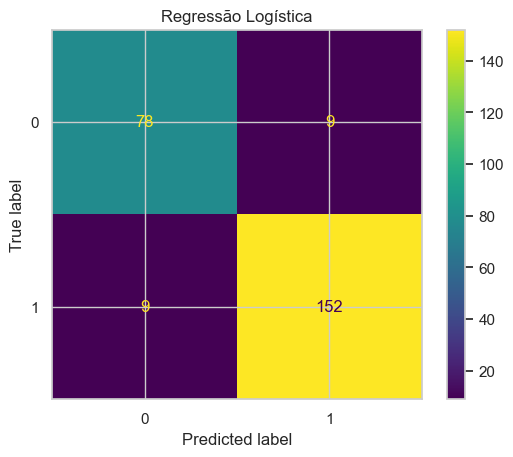

KNN
              precision    recall  f1-score   support

           0       0.90      0.89      0.89        87
           1       0.94      0.94      0.94       161

    accuracy                           0.92       248
   macro avg       0.92      0.91      0.92       248
weighted avg       0.92      0.92      0.92       248



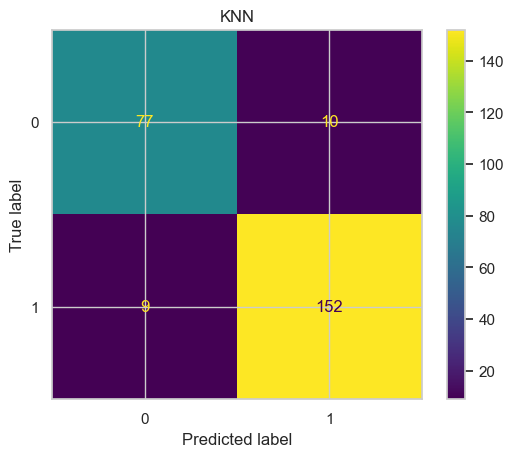

Árvore de Decisão
              precision    recall  f1-score   support

           0       0.83      0.84      0.83        87
           1       0.91      0.91      0.91       161

    accuracy                           0.88       248
   macro avg       0.87      0.87      0.87       248
weighted avg       0.88      0.88      0.88       248



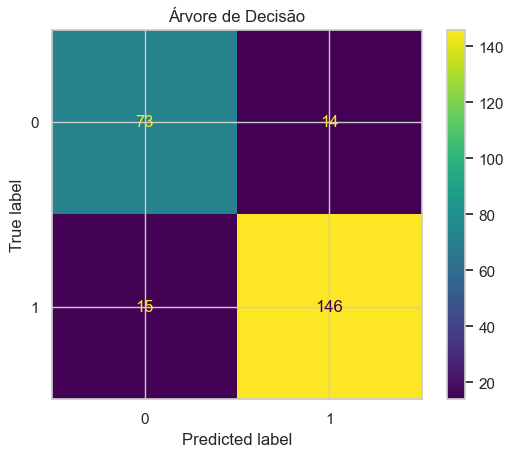

SVM
              precision    recall  f1-score   support

           0       0.90      0.89      0.89        87
           1       0.94      0.94      0.94       161

    accuracy                           0.92       248
   macro avg       0.92      0.91      0.92       248
weighted avg       0.92      0.92      0.92       248



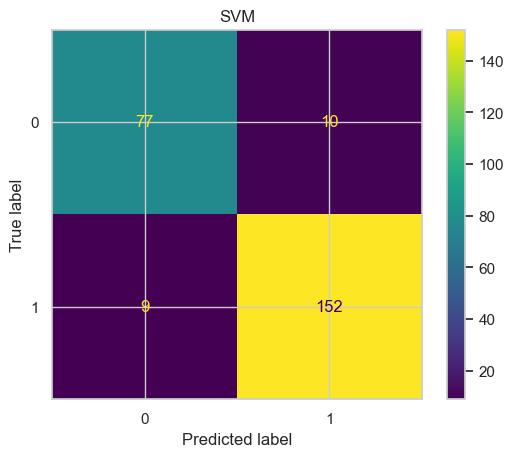

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resultados = []

for nome, config in classificacao.items():
        
        pipeline = Pipeline([('padronizacao', StandardScaler()), ('modelo', config['modelo'])])
        
        grid_search = GridSearchCV(pipeline, config['params'], cv=5, scoring='accuracy')
        
        grid_search.fit(X_treino, y_treino)
        
        melhor_modelo = grid_search.best_estimator_
        
        y_pred = melhor_modelo.predict(X_teste)
        
        print(nome)
        print(classification_report(y_teste, y_pred))
        
        matriz_conf = confusion_matrix(y_teste, y_pred)
        ConfusionMatrixDisplay(matriz_conf).plot()
        plt.title(nome)
        plt.show()
        
        acuracia = accuracy_score(y_teste, y_pred)
        f1 = f1_score(y_teste, y_pred)
        recall = recall_score(y_teste, y_pred)
        precisao = precision_score(y_teste, y_pred)

        resultados.append({
            'Modelo': nome,
            'Acurácia': acuracia,
            'F1-Score': f1,
            'Recall': recall,
            'Precisão': precisao,
            'Melhores Parâmetros': grid_search.best_params_
        })

df_resultados = pd.DataFrame(resultados).sort_values(by='Acurácia', ascending=False)
display(df_resultados)
    
    


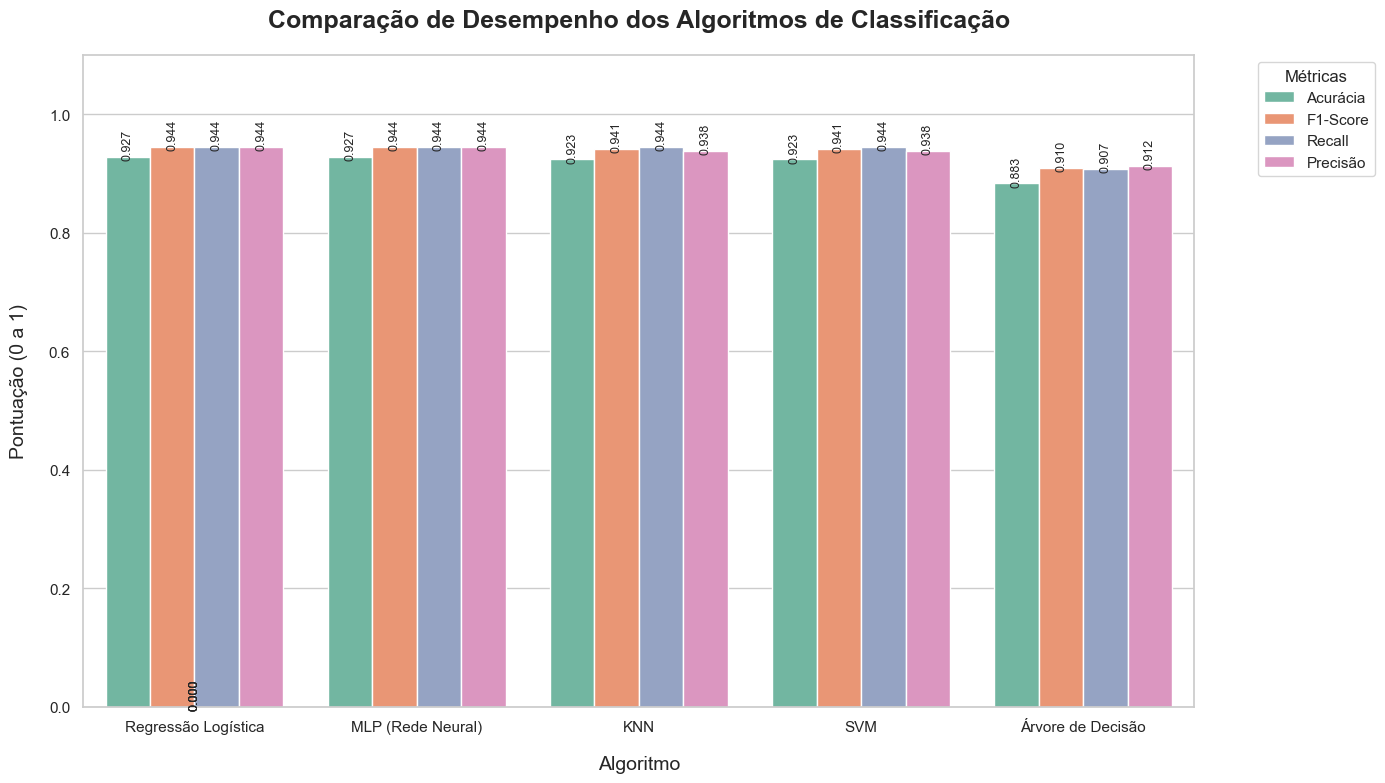

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_melted = df_resultados.melt(
    id_vars='Modelo', 
    value_vars=['Acurácia', 'F1-Score', 'Recall', 'Precisão'],
    var_name='Métrica', 
    value_name='Pontuação'
)


plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Modelo', 
    y='Pontuação', 
    hue='Métrica', 
    data=df_melted, 
    palette='Set2' 
)

plt.title('Comparação de Desempenho dos Algoritmos de Classificação', fontsize=18, pad=20, weight='bold')
plt.xlabel('Algoritmo', fontsize=14, labelpad=15)
plt.ylabel('Pontuação (0 a 1)', fontsize=14, labelpad=15)


for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9,
                rotation=90)

plt.ylim(0, 1.1)
plt.legend(title='Métricas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

Electric Vehicle Charging Patterns
Analyze EV charging patterns, energy usage, and user behavior in various models.


This dataset provides a comprehensive analysis of electric vehicle (EV) charging patterns and user behavior. It contains 1,320 samples of charging session data, including metrics such as energy consumption, charging duration, and vehicle details. Each entry captures various aspects of EV usage, allowing for insightful analysis and predictive modeling.

In [16]:
dados = pd.read_csv('ev_charging_patterns.csv')
dados.head(3)   

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter


In [63]:
dados.drop('User ID', axis=1, inplace=True)
dados.drop('Charging Station ID', axis=1, inplace=True)
dados.drop('Charging Start Time', axis=1, inplace=True)
dados.drop('Charging End Time', axis=1, inplace=True)


In [ ]:
dados.info()

In [ ]:
dados.isnull().sum()

In [ ]:
dados.fillna(dados.mean(numeric_only=True), inplace=True)

In [67]:
dados = pd.get_dummies(dados)

In [ ]:
dados.describe()

In [69]:
X = dados.drop('Charging Cost (USD)', axis=1).values
y = dados['Charging Cost (USD)'].values

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state=7)

In [ ]:
dados.head(3)

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

modelos_regressao = {
    'Regressão Linear': {
        'modelo': LinearRegression(),
        'params': {}
    },
    'KNN Regressor': {
        'modelo': KNeighborsRegressor(),
        'params': {'regressor__n_neighbors': [3, 5, 9], 'regressor__weights': ['uniform', 'distance']}
    },
    'Árvore de Decisão': {
        'modelo': DecisionTreeRegressor(random_state=42),
        'params': {'regressor__max_depth': [5, 10], 'regressor__min_samples_split': [2, 5]}
    },
    'SVR (Máquina de Vetores de Suporte)': {
        'modelo': SVR(),
        'params': {'regressor__C': [1, 10], 'regressor__kernel': ['linear', 'rbf']}
    },
    'MLP Regressor (Rede Neural)': {
        'modelo': MLPRegressor(max_iter=2000, random_state=42),
        'params': {
            'regressor__hidden_layer_sizes': [(50,)],'regressor__activation': ['relu']
        }
    }
}



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    
resultados_regressao = []

for nome, config in modelos_regressao.items():
    
    pipeline = Pipeline([('pre_processamento', StandardScaler()),('regressor', config['modelo'])])
    
    grid_search = GridSearchCV(pipeline, config['params'], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    
    grid_search.fit(X_treino, y_treino)
    
    melhor_modelo = grid_search.best_estimator_
    
    y_pred = melhor_modelo.predict(X_teste)
    
    mse = mean_squared_error(y_teste, y_pred)
    rmse = np.sqrt(mse) 
    mae = mean_absolute_error(y_teste, y_pred)
    r2 = r2_score(y_teste, y_pred) 
    
    resultados_regressao.append({
        'Modelo': nome,
        'R²': r2,
        'RMSE': rmse,
        'MSE': mse,
        'MAE': mae
    })

df_resultados_reg = pd.DataFrame(resultados_regressao).sort_values(by='R²', ascending=False)
display(df_resultados_reg)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten() 

sns.set_theme(style="whitegrid")

for i, (nome, config) in enumerate(modelos_regressao.items()):
    
    print(f"Gerando gráfico para: {nome}...")
    
    pipeline_plot = Pipeline([
        ('scaler', StandardScaler()), 
        ('regressor', config['modelo'])
    ])
    pipeline_plot.fit(X_treino, y_treino)
    y_pred_plot = pipeline_plot.predict(X_teste)
    
    sns.regplot(
        x=y_teste, 
        y=y_pred_plot, 
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 'color': '#1f77b4', 's': 30}, 
        line_kws={'color': 'red', 'linewidth': 3, 'label': 'Tendência do Modelo'}
    )
    
    min_val = min(y_teste.min(), y_pred_plot.min())
    max_val = max(y_teste.max(), y_pred_plot.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], color='green', linestyle='--', linewidth=2, label='Ideal (y = x)')
    
    axes[i].set_title(nome, fontsize=18, weight='bold', pad=15)
    axes[i].set_xlabel('Valor Real (Energia)', fontsize=14)
    axes[i].set_ylabel('Valor Previsto (Energia)', fontsize=14)
    
    axes[i].tick_params(axis='both', labelsize=12)
    axes[i].legend(fontsize=12)

if len(modelos_regressao) < 6:
    fig.delaxes(axes[5])

plt.tight_layout(pad=4.0)
plt.show()